In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df = sns.load_dataset('titanic')
feature_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
df = df.dropna(subset=feature_cols + ['survived'])

X = df[feature_cols].copy()
y = df['survived'].copy()

X.describe()

,pclass,age,sibsp,parch,fare
count,714.000000,714.000000,714.000000,714.000000,714.000000
mean,2.236695,29.699118,0.512605,0.431373,34.694514
std,0.838250,14.526497,0.929783,0.853289,52.918930
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,1.000000,20.125000,0.000000,0.000000,8.050000
50%,2.000000,28.000000,0.000000,0.000000,15.741700
75%,3.000000,38.000000,1.000000,1.000000,33.375000
max,3.000000,80.000000,5.000000,6.000000,512.329200


In [2]:
scalers = {
    'raw (unscaled)': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(),
}

def run_experiment(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    rows = []
    for scaler_name, scaler in scalers.items():
        if scaler is None:
            X_train_t, X_test_t = X_train.values, X_test.values
        else:
            X_train_t = scaler.fit_transform(X_train)
            X_test_t = scaler.transform(X_test)

        for model_name, model in models.items():
            model = type(model)(**model.get_params())
            model.fit(X_train_t, y_train)
            acc = accuracy_score(y_test, model.predict(X_test_t))
            rows.append({'dataset': label, 'model': model_name, 'scaler': scaler_name, 'accuracy': acc})

    return pd.DataFrame(rows)

In [3]:
results_clean = run_experiment(X, y, 'original')
results_clean.pivot(index='model', columns='scaler', values='accuracy')

scaler,MinMaxScaler,RobustScaler,StandardScaler,raw (unscaled)
model,,,,
KNN (k=5),0.650350,0.671329,0.650350,0.615385
SVM,0.734266,0.706294,0.706294,0.685315


In [4]:
rng = np.random.default_rng(42)
n_outliers = 5

outliers = pd.DataFrame({
    'pclass': X['pclass'].sample(n_outliers, random_state=1).values,
    'age': X['age'].max() * rng.uniform(5, 8, size=n_outliers),
    'sibsp': X['sibsp'].max() * rng.uniform(5, 10, size=n_outliers),
    'parch': X['parch'].max() * rng.uniform(5, 10, size=n_outliers),
    'fare': X['fare'].max() * rng.uniform(5, 10, size=n_outliers),
})

outlier_labels = pd.Series(rng.integers(0, 2, size=n_outliers), index=outliers.index)

X_with_outliers = pd.concat([X, outliers], ignore_index=True)
y_with_outliers = pd.concat([y.reset_index(drop=True), outlier_labels], ignore_index=True)

print('New rows added:', n_outliers)
outliers

New rows added: 5


,pclass,age,sibsp,parch,fare
0,1,585.749452,49.390559,41.123941,3143.751163
1,3,505.330826,44.028493,57.802950,3982.295901
2,2,606.063501,44.651608,49.315954,2725.123219
3,2,567.368327,28.202841,54.682848,4681.744081
4,3,422.602563,36.259648,43.302426,4179.746581


In [5]:
results_outliers = run_experiment(X_with_outliers, y_with_outliers, 'with_outliers')
results_outliers.pivot(index='model', columns='scaler', values='accuracy')

scaler,MinMaxScaler,RobustScaler,StandardScaler,raw (unscaled)
model,,,,
KNN (k=5),0.680556,0.687500,0.659722,0.645833
SVM,0.611111,0.666667,0.687500,0.666667


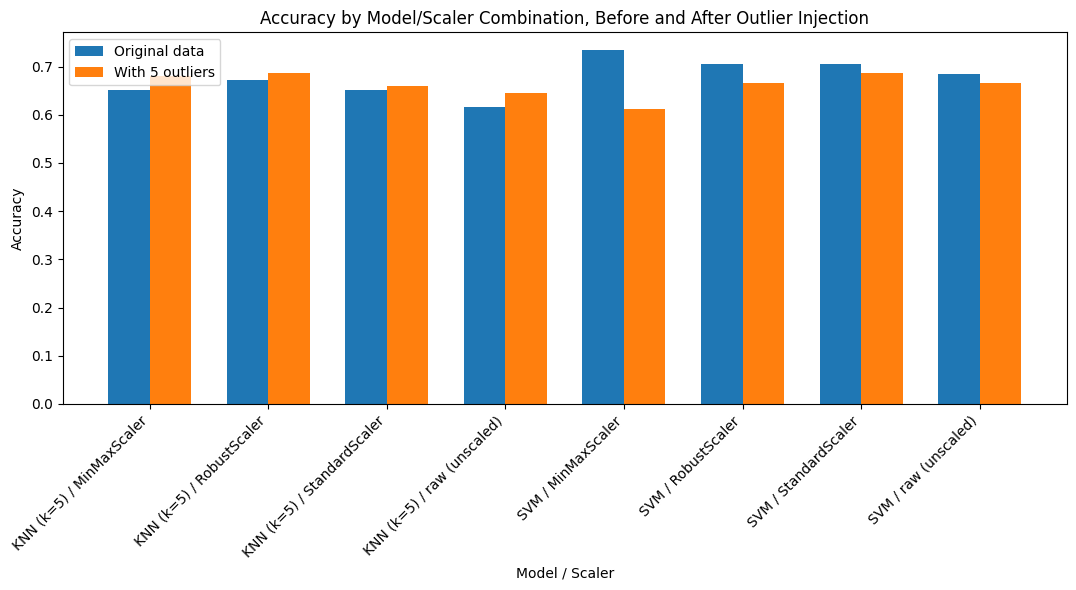

In [6]:
all_results = pd.concat([results_clean, results_outliers], ignore_index=True)
all_results['combo'] = all_results['model'] + ' / ' + all_results['scaler']

pivot = all_results.pivot(index='combo', columns='dataset', values='accuracy')

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(pivot.index))
width = 0.35

ax.bar(x - width/2, pivot['original'], width, label='Original data')
ax.bar(x + width/2, pivot['with_outliers'], width, label='With 5 outliers')

ax.set_title('Accuracy by Model/Scaler Combination, Before and After Outlier Injection')
ax.set_xlabel('Model / Scaler')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
all_results['accuracy_drop'] = all_results.groupby(['model', 'scaler'])['accuracy'].transform(
    lambda s: s.iloc[0] - s.iloc[1] if len(s) == 2 else np.nan
)

drop_by_scaler = all_results.groupby('scaler')['accuracy_drop'].mean().sort_values()
print('Average accuracy drop after adding outliers, by scaler (smaller = more robust):')
print(drop_by_scaler)

most_robust = drop_by_scaler.idxmin()
print(f'\nMost robust scaler overall: {most_robust}')

Average accuracy drop after adding outliers, by scaler (smaller = more robust):
scaler
raw (unscaled)   -0.005900
StandardScaler    0.004711
RobustScaler      0.011728
MinMaxScaler      0.046474
Name: accuracy_drop, dtype: float64

Most robust scaler overall: raw (unscaled)


In [8]:
print('Average accuracy drop after adding outliers, by scaler (smaller/more negative = more robust):')
print(drop_by_scaler.round(4))

print(
    f"\nFor this run, '{most_robust}' showed the smallest average accuracy drop "
    f"({drop_by_scaler[most_robust]:+.4f}) after the outliers were added, making it the most "
    f"robust option among those tested here.\n\n"
    f"Practical takeaway for ML practitioners: scaler robustness to outliers should be checked "
    f"empirically on the dataset at hand, as in this experiment, rather than assumed. "
    f"RobustScaler is designed specifically to resist the influence of extreme values (via the "
    f"median and interquartile range) and is a reasonable default starting point for distance-based models such as KNN and SVM when outliers are a known risk, but the actual best "
    f"choice can vary by dataset, as shown above."
)

Average accuracy drop after adding outliers, by scaler (smaller/more negative = more robust):
scaler
raw (unscaled)   -0.0059
StandardScaler    0.0047
RobustScaler      0.0117
MinMaxScaler      0.0465
Name: accuracy_drop, dtype: float64

For this run, 'raw (unscaled)' showed the smallest average accuracy drop (-0.0059) after the outliers were added, making it the most robust option among those tested here.

Practical takeaway for ML practitioners: scaler robustness to outliers should be checked empirically on the dataset at hand, as in this experiment, rather than assumed. RobustScaler is designed specifically to resist the influence of extreme values (via the median and interquartile range) and is a reasonable default starting point for distance-based models such as KNN and SVM when outliers are a known risk, but the actual best choice can vary by dataset, as shown above.
